## Example-62: Kick map (element)

In [1]:
# In this example AT style kick map element is illustrated
# The kick table is generated with Radia and saved as a mat file
# Effect on linear optics from linear ID model and kick map are compared
# Horizontal phase space trajectories are compared with and without ID

In [2]:
# Import

import torch
from torch import Tensor

from pathlib import Path
from tqdm import tqdm

import matplotlib
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle
matplotlib.rcParams['text.usetex'] = True

from model.library.element import Element
from model.library.line import Line
from model.library.corrector import Corrector
from model.library.quadrupole import Quadrupole
from model.library.matrix import Matrix
from model.library.kickmap import KM

from model.command.external import load_lattice
from model.command.build import build
from model.command.tune import tune
from model.command.tune import chromaticity
from model.command.orbit import dispersion
from model.command.orbit import ORM
from model.command.twiss import twiss
from model.command.advance import advance
from model.command.coupling import coupling

In [3]:
# Set data type and device

Element.dtype = dtype = torch.float64
Element.device = device = torch.device('cpu')

In [4]:
# Load lattice (ELEGANT table)
# Note, lattice is allowed to have repeated elements

path = Path('elettra.lte')
data = load_lattice(path)

In [5]:
# Build and setup lattice

ring:Line = build('RING', 'ELEGANT', data)

# Flatten sublines

ring.flatten()

# Remove all marker elements but the ones starting with MLL (long straight section centers)

ring.remove_group(pattern=r'^(?!MSS_)(?!MLL_).*', kinds=['Marker'])


# Set sextupole integration order and step size

ring.order = (('Sextupole', 1), )
ring.ns = (('Sextupole', 0.01), )

# Set linear dipoles

def apply(element:Element) -> None:
    element.linear = True

ring.apply(apply, kinds=['Dipole'])

# Insert correctors

for name, *_ in ring.layout():
    if name.startswith('CH'):
        corrector = Corrector(f'{name}_CXY', factor=1)
        ring.split((1 + 1, None, [name], None), paste=[corrector])

# Merge drifts

ring.merge()

# Change lattice start start

ring.start = "BPM_S01_01"

# Split BPMs

ring.split((None, ['BPM'], None, None))

# Roll lattice

ring.roll(1)

# Splice

ring.splice()

# Describe

ring.describe

{'BPM': 168,
 'Drift': 744,
 'Dipole': 156,
 'Sextupole': 240,
 'Quadrupole': 120,
 'Corrector': 24,
 'Marker': 24}

In [6]:
# Compute tunes (fractional part)

nux, nuy = tune(ring, [], matched=True, limit=1)

In [7]:
# Compute dispersion

orbit = torch.tensor(4*[0.0], dtype=dtype, device=device)
etaqx, etapx, etaqy, etapy = dispersion(ring, orbit, [], limit=1)

In [8]:
# Compute twiss parameters

ax, bx, ay, by = twiss(ring, [], matched=True, advance=True, full=False).T

In [9]:
# Compute phase advances

mux, muy = advance(ring, [], alignment=False, matched=True).T

In [10]:
# Compute coupling

c = coupling(ring, [])

In [11]:
# Compute chromaticity

psi = chromaticity(ring, [], matched=True)

In [12]:
# Define ID (linear model)

A = torch.tensor([[-0.0344386, 0., 0., 0.], [0., -0.0445673, 0., 0.], [0., 0., 0.056303, 0.], [0., 0., 0., 0.0804237]], dtype=dtype)

CENTER = 0.0
ID = Matrix('ID', length=0.0, A=A[torch.triu(torch.ones_like(A, dtype=torch.bool))].tolist())

In [13]:
# Insert ID (linear model)

error = ring.clone()
error.flatten()
error.insert(ID, error.next('MLL_S01').name, position=CENTER*1.0E-3)
error.splice()
error.describe

{'BPM': 168,
 'Drift': 745,
 'Dipole': 156,
 'Sextupole': 240,
 'Quadrupole': 120,
 'Corrector': 24,
 'Marker': 24,
 'Matrix': 1}

In [14]:
# Compute tunes (fractional part)

nux_id_lm, nuy_id_lm = tune(error, [], matched=True, limit=1)

In [15]:
# Compute dispersion

orbit = torch.tensor(4*[0.0], dtype=dtype)
etaqx_id_lm, etapx_id_lm, etaqy_id_lm, etapy_id_lm = dispersion(error, orbit, [], limit=1)

In [16]:
# Compute twiss parameters

ax_id_lm, bx_id_lm, ay_id_lm, by_id_lm = twiss(error, [], matched=True, advance=True, full=False).T

In [17]:
# Compute phase advances

mux_id_lm, muy_id_lm = advance(error, [], alignment=False, matched=True).T

In [18]:
# Compute coupling

c_id_lm = coupling(error, [])

In [19]:
# Compute chromaticity

psi_id_lm = chromaticity(error, [])

In [20]:
# Define ID (load kick map)

CENTER = 0.0
ID = KM(name='ID', path=Path('id.mat'), energy=2.4, count=40, insertion=True)

In [21]:
# Insert ID (kick map)

error = ring.clone()
error.flatten()
error.insert(ID, error.next('MLL_S01').name, position=CENTER*1.0E-3)
error.splice()
error.describe

{'BPM': 168,
 'Drift': 745,
 'Dipole': 156,
 'Sextupole': 240,
 'Quadrupole': 120,
 'Corrector': 24,
 'Marker': 24,
 'KM': 1}

In [22]:
# Compute tunes (fractional part)

nux_id_km, nuy_id_km = tune(error, [], matched=True, limit=1)

In [23]:
# Compute dispersion

orbit = torch.tensor(4*[0.0], dtype=dtype)
etaqx_id_km, etapx_id_km, etaqy_id_km, etapy_id_km = dispersion(error, orbit, [], limit=1)

In [24]:
# Compute twiss parameters

ax_id_km, bx_id_km, ay_id_km, by_id_km = twiss(error, [], matched=True, advance=True, full=False).T

In [25]:
# Compute phase advances

mux_id_km, muy_id_km = advance(error, [], alignment=False, matched=True).T

In [26]:
# Compute coupling

c_id_km = coupling(error, [])

In [27]:
# Compute chromaticity

psi_id_km = chromaticity(error, [])

In [28]:
# Tune shifts

print((nux - nux_id_lm))
print((nuy - nuy_id_lm))
print()

print((nux - nux_id_km))
print((nuy - nuy_id_km))
print()

tensor(0.0257, dtype=torch.float64)
tensor(-0.0112, dtype=torch.float64)

tensor(0.0256, dtype=torch.float64)
tensor(-0.0113, dtype=torch.float64)



In [29]:
# Coupling (minimal tune distance)

print(c)
print(c_id_lm)
print(c_id_km)

tensor(0., dtype=torch.float64)
tensor(0., dtype=torch.float64)
tensor(9.8422e-09, dtype=torch.float64)


In [30]:
# Chromaticity

print(psi)
print(psi_id_lm)
print(psi_id_km)

tensor([2.0296, 2.0131], dtype=torch.float64)
tensor([3.2067, 1.5121], dtype=torch.float64)
tensor([3.2342, 1.4944], dtype=torch.float64)


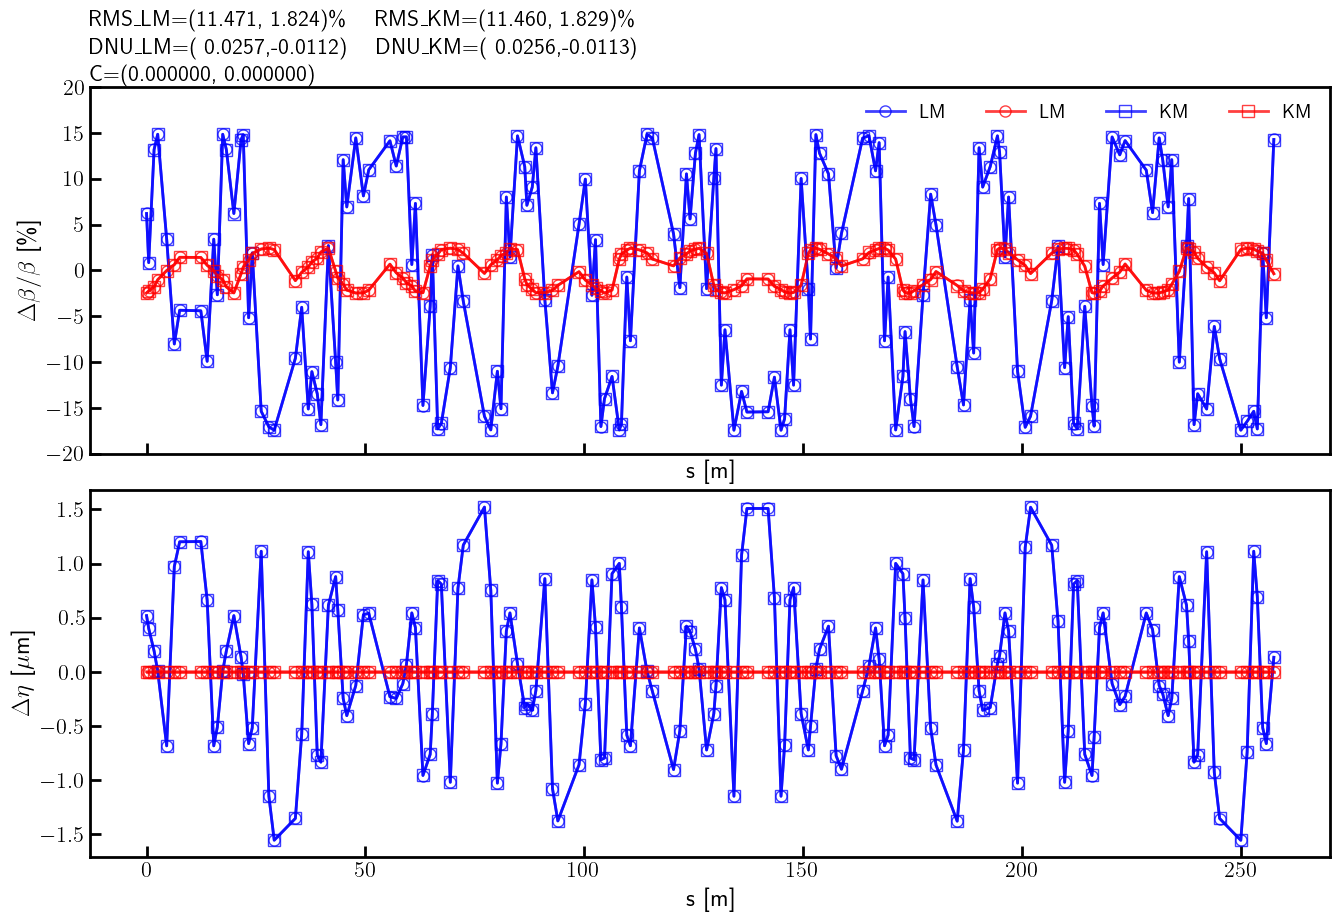

In [31]:
# Beta-beating and dispersion

def rms(x):
    return (x**2).mean().sqrt()

bx_bb_lm = 100.0*(bx - bx_id_lm) / bx
by_bb_lm = 100.0*(by - by_id_lm) / by

bx_bb_km = 100.0*(bx - bx_id_km) / bx
by_bb_km = 100.0*(by - by_id_km) / by

rms_x_lm = rms(bx_bb_lm).item()
ptp_x_lm = (bx_bb_lm.max() - bx_bb_lm.min()).item()
rms_y_lm = rms(by_bb_lm).item()
ptp_y_lm = (by_bb_lm.max() - by_bb_lm.min()).item()

rms_x_km = rms(bx_bb_km).item()
ptp_x_km = (bx_bb_km.max() - bx_bb_km.min()).item()
rms_y_km = rms(by_bb_km).item()
ptp_y_km = (by_bb_km.max() - by_bb_km.min()).item()

s = ring.locations().cpu().numpy()

bx_np_lm = bx_bb_lm.cpu().numpy()
by_np_lm = by_bb_lm.cpu().numpy()

bx_np_km = bx_bb_km.cpu().numpy()
by_np_km = by_bb_km.cpu().numpy()

etax_lm = etaqx - etaqx_id_lm
etay_lm = etaqy - etaqy_id_lm

etax_km = etaqx - etaqx_id_km
etay_km = etaqy - etaqy_id_km

rms_etax_lm = rms(etax_lm).item()
ptp_etax_lm = (etax_lm.max() - etax_lm.min()).item()
rms_etay_lm = rms(etay_lm).item()
ptp_etay_lm = (etay_lm.max() - etay_lm.min()).item()

rms_etax_km = rms(etax_km).item()
ptp_etax_km = (etax_km.max() - etax_km.min()).item()
rms_etay_km = rms(etay_km).item()
ptp_etaf_km = (etay_km.max() - etay_km.min()).item()

etax_np_lm = etax_lm.cpu().numpy()
etay_np_lm = etay_lm.cpu().numpy()

etax_np_km = etax_km.cpu().numpy()
etay_np_km = etay_km.cpu().numpy()

fig, (ax, ay) = plt.subplots(2, 1, figsize=(16, 10), sharex=True, gridspec_kw={'hspace': 0.1})

ax.errorbar(s, bx_np_lm, fmt='-', marker='o', color='blue', alpha=0.75, lw=2.0, label=r'LM', markerfacecolor='none', ms=8)
ax.errorbar(s, by_np_lm, fmt='-', marker='o', color='red',  alpha=0.75, lw=2.0, label=r'LM', markerfacecolor='none', ms=8)

ax.errorbar(s, bx_np_km, fmt='-', marker='s', color='blue', alpha=0.75, lw=2.0, label=r'KM', markerfacecolor='none', ms=8)
ax.errorbar(s, by_np_km, fmt='-', marker='s', color='red',  alpha=0.75, lw=2.0, label=r'KM', markerfacecolor='none', ms=8)

ax.set_xlabel('s [m]', fontsize=18)
ax.set_ylabel(r'$\Delta \beta / \beta$ [\%]', fontsize=18)
ax.tick_params(width=2, labelsize=16)
ax.tick_params(axis='x', length=8, direction='in')
ax.tick_params(axis='y', length=8, direction='in')
title = (
    rf'RMS_LM=({rms_x_lm:6.3f},{rms_y_lm:6.3f})\% \quad '
    rf'RMS_KM=({rms_x_km:6.3f},{rms_y_km:6.3f})\% \quad '
)
ax.text(0.0, 1.15, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')

title = (
    rf'DNU_LM=({(lambda x: '-' if x < 0 else '~')(nux - nux_id_lm)}{(nux - nux_id_lm).abs().item():05.4f},{(lambda x: '-' if x < 0 else '~')(nuy - nuy_id_lm)}{(nuy - nuy_id_lm).abs().item():05.4f}) \quad '
    rf'DNU_KM=({(lambda x: '-' if x < 0 else '~')(nux - nux_id_km)}{(nux - nux_id_km).abs().item():05.4f},{(lambda x: '-' if x < 0 else '~')(nuy - nuy_id_km)}{(nuy - nuy_id_km).abs().item():05.4f}) \quad '
)
ax.text(0.0, 1.075, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')

title = (
    rf'\quad C=({c_id_lm.item():.6f}, {c_id_km.item():.6f})'
)
ax.text(0.0, 1.00, title, transform=ax.transAxes, ha='left', va='bottom', fontsize=16, fontfamily='monospace')
ax.legend(loc='upper right', frameon=False, fontsize=14, ncol=6)
ax.set_ylim(-20, 20)

ay.errorbar(s, 10**6*etax_np_lm, fmt='-', marker='o', color='blue', alpha=0.75, lw=2.0, label=r'LM', markerfacecolor='none', ms=8)
ay.errorbar(s, 10**6*etay_np_lm, fmt='-', marker='o', color='red', alpha=0.75, lw=2.0, label=r'LM', markerfacecolor='none', ms=8)

ay.errorbar(s, 10**6*etax_np_km, fmt='-', marker='s', color='blue', alpha=0.75, lw=2.0, label=r'KM', markerfacecolor='none', ms=8)
ay.errorbar(s, 10**6*etay_np_km, fmt='-', marker='s', color='red', alpha=0.75, lw=2.0, label=r'KM', markerfacecolor='none', ms=8)

ay.set_xlabel('s [m]', fontsize=18)
ay.set_ylabel(r'$\Delta \eta$ [$\mu$m]', fontsize=18)
ay.tick_params(width=2, labelsize=16)
ay.tick_params(axis='x', length=8, direction='in')
ay.tick_params(axis='y', length=8, direction='in')


plt.setp(ax.spines.values(), linewidth=2.0)
plt.setp(ay.spines.values(), linewidth=2.0)
plt.show()

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1024/1024 [18:19<00:00,  1.07s/it]


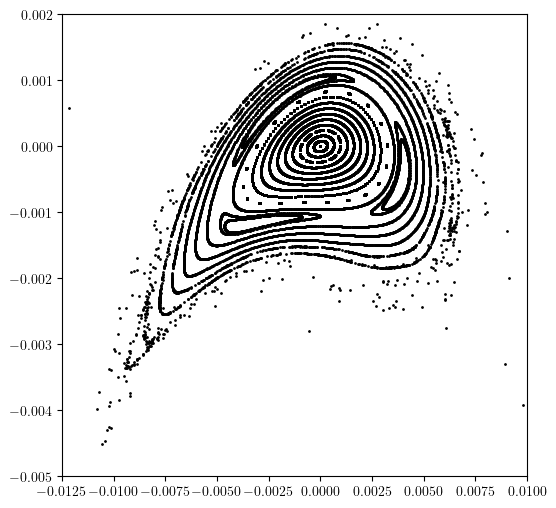

In [32]:
# Phase space without ID

qx = torch.linspace(0.0, 0.01, 32, dtype=torch.float64)
px = torch.zeros_like(qx)
qy = torch.zeros_like(qx)
py = torch.zeros_like(qx)

state = torch.stack([qx, px, qy, py]).T
orbit = []

for _ in tqdm(range(2**10)):
    state = torch.vmap(ring)(state)
    orbit.append(state)

qx, px, *_ = torch.stack(orbit).swapaxes(0, -1)

plt.figure(figsize=(6, 6))
plt.scatter(qx.cpu().numpy(), px.cpu().numpy(), s=1, color='black')
plt.xlim(-0.0125, 0.0100)
plt.ylim(-0.005, 0.002)
plt.show()

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1024/1024 [19:02<00:00,  1.12s/it]


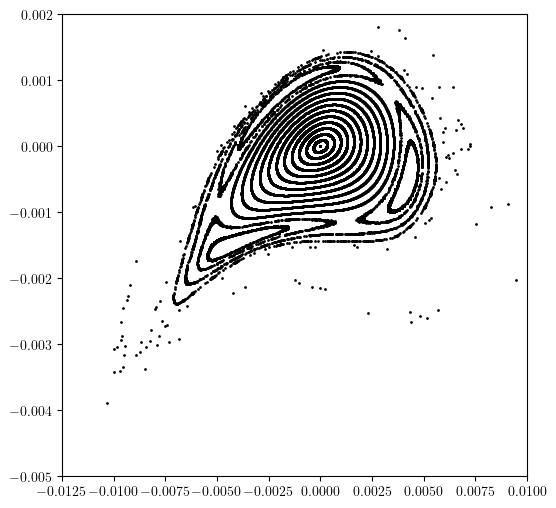

In [33]:
# Phase space with ID

qx = torch.linspace(0.0, 0.01, 32, dtype=torch.float64)
px = torch.zeros_like(qx)
qy = torch.zeros_like(qx)
py = torch.zeros_like(qx)

state = torch.stack([qx, px, qy, py]).T
orbit = []

for _ in tqdm(range(2**10)):
    state = torch.vmap(error)(state)
    orbit.append(state)

qx, px, *_ = torch.stack(orbit).swapaxes(0, -1)

plt.figure(figsize=(6, 6))
plt.scatter(qx.cpu().numpy(), px.cpu().numpy(), s=1, color='black')
plt.xlim(-0.0125, 0.0100)
plt.ylim(-0.005, 0.002)
plt.show()